In [ ]:
!pip install timm scikit-learn pytorch-metric-learning -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 3.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pytorch_metric_learning import miners, losses
from pytorch_metric_learning.losses import ArcFaceLoss
from pytorch_metric_learning.samplers import MPerClassSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score


print("Setup complete!")

Setup complete!


In [ ]:
# import os
# import random
# import shutil
# from pathlib import Path

# # Folder that currently contains cow1, cow2, cow3, etc.
# SOURCE_DIR = Path("/content/drive/MyDrive/Cow Verification System/cow-muzzle-dataset/cropped_grouped_agglomerative")

# # New output folder
# OUTPUT_DIR = Path("/content/drive/MyDrive/Cow Verification System/cow-muzzle-dataset/cropped_grouped_agglomerative_split")

# TRAIN_RATIO = 0.8
# random.seed(42)

# train_dir = OUTPUT_DIR / "train"
# valid_dir = OUTPUT_DIR / "valid"

# train_dir.mkdir(parents=True, exist_ok=True)
# valid_dir.mkdir(parents=True, exist_ok=True)

# # Get only cow folders
# cow_folders = [
#     folder for folder in SOURCE_DIR.iterdir()
#     if folder.is_dir() and folder.name not in ["train", "val", "valid", "test"]
# ]

# random.shuffle(cow_folders)

# split_index = int(len(cow_folders) * TRAIN_RATIO)

# train_cows = cow_folders[:split_index]
# valid_cows = cow_folders[split_index:]

# def copy_cow_folders(cows, target_dir):
#     for cow_folder in cows:
#         destination = target_dir / cow_folder.name

#         if destination.exists():
#             shutil.rmtree(destination)

#         shutil.copytree(cow_folder, destination)

# copy_cow_folders(train_cows, train_dir)
# copy_cow_folders(valid_cows, valid_dir)

# print(f"Total cows: {len(cow_folders)}")
# print(f"Train cows: {len(train_cows)}")
# print(f"Valid cows: {len(valid_cows)}")
# print("Cow-folder split completed!")

In [ ]:
from pathlib import Path
import shutil

DATA_ROOT = Path("/content/drive/MyDrive/Cow Verification System/cow-muzzle-dataset/cropped_grouped_agglomerative_split")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Set True first to preview. Change to False to actually delete.
DRY_RUN = True

removed_folders = []

for split in ["train", "valid"]:
    split_dir = DATA_ROOT / split

    if not split_dir.exists():
        print(f"Missing split folder: {split_dir}")
        continue

    for cow_folder in split_dir.iterdir():
        if not cow_folder.is_dir():
            continue

        image_dir = cow_folder / "images"

        if not image_dir.exists():
            print(f"Skipping, no images folder: {cow_folder}")
            continue

        image_files = [
            f for f in image_dir.iterdir()
            if f.is_file() and f.suffix.lower() in IMAGE_EXTS
        ]

        if len(image_files) <= 1:
            removed_folders.append(str(cow_folder))

            if DRY_RUN:
                print(f"[DRY RUN] Would remove: {cow_folder} | images: {len(image_files)}")
            else:
                shutil.rmtree(cow_folder)
                print(f"Removed: {cow_folder}")

print("\nTotal folders with only 1 image:", len(removed_folders))


Total folders with only 1 image: 0


In [ ]:
path = "/content/drive/MyDrive/Cow Verification System/cow-muzzle-dataset/cropped_grouped_agglomerative_split"
train_path = os.path.join(path, "train")
val_path = os.path.join(path, "valid")

# Quick check
train_cows = [d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))]
val_cows = [d for d in os.listdir(val_path) if os.path.isdir(os.path.join(val_path, d))]

print(f"Total train cows: {len(train_cows)}")
print(f"Total val cows: {len(val_cows)}")

Total train cows: 152
Total val cows: 38


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),

    # ✅ MUCH stronger photometric augmentation
    transforms.ColorJitter(
        brightness=0.8,   # was 0.3 — now covers dark & overexposed
        contrast=0.6,     # was 0.3
        saturation=0.7,   # was 0.3 — covers heavy saturation
        hue=0.15
    ),

    # ✅ Add these — they simulate real camera/lighting differences
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomEqualize(p=0.2),       # histogram equalization
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.RandomGrayscale(p=0.1),
    #transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    #transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
class TripletDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = [
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ]

        self.class_to_images = {}

        for cls in self.classes:
            # fixed path: train/cow1/image/
            image_dir = os.path.join(root_dir, cls, "images")

            if not os.path.isdir(image_dir):
                continue

            images = [
                os.path.join(image_dir, img)
                for img in os.listdir(image_dir)
                if img.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
            ]

            if len(images) >= 2:
                self.class_to_images[cls] = images

        self.classes = list(self.class_to_images.keys())
        self.img_paths = []
        self.labels = []

        for i, cls in enumerate(self.classes):
            for path in self.class_to_images[cls]:
                self.img_paths.append(path)
                self.labels.append(i)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]

In [ ]:
train_dataset = TripletDataset(train_path, transform=train_transform)
val_dataset = TripletDataset(val_path, transform=val_transform)

train_sampler = MPerClassSampler(
    labels=train_dataset.labels,
    m=4,
    batch_size=32,
    length_before_new_iter=len(train_dataset)
)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=4, sampler=train_sampler, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

images, labels = next(iter(train_loader))

print(images.shape)

Train samples: 1079, Val samples: 282


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

torch.Size([32, 3, 224, 224])


In [ ]:
class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.fc = nn.Linear(2048, embedding_dim)

    def forward(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return nn.functional.normalize(x, p=2, dim=1)

model = EmbeddingNet(embedding_dim=128)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model moved to {device}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


Model moved to cpu


In [ ]:
miner = miners.BatchHardMiner()
criterion = losses.TripletMarginLoss(margin=1.0)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, miner, device):
    model.train()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device).long().view(-1)

        optimizer.zero_grad()
        embeddings = model(images)

        a_idx, p_idx, n_idx = miner(embeddings, labels)
        if len(a_idx) == 0:  # rare case
            continue

        loss = criterion(embeddings, labels, (a_idx, p_idx, n_idx))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader) if len(loader) > 0 else 0.0


def validate(model, loader, criterion, miner, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device).long().view(-1)
            embeddings = model(images)
            a_idx, p_idx, n_idx = miner(embeddings, labels)

            if len(a_idx) == 0:
                continue

            loss = criterion(embeddings, labels, (a_idx, p_idx, n_idx))
            total_loss += loss.item()

    return total_loss / len(loader) if len(loader) > 0 else 0.0

In [ ]:
def compute_verification_metrics_with_threshold(model, loader, device):
    model.eval()

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            embeddings = model(images)

            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels.cpu())

    embeddings = torch.cat(all_embeddings, dim=0)
    labels = torch.cat(all_labels, dim=0)

    # Since embeddings are already L2-normalized, dot product = cosine similarity
    sim_matrix = embeddings @ embeddings.T

    label_matrix = labels.unsqueeze(1) == labels.unsqueeze(0)

    # Remove self-comparisons
    mask = ~torch.eye(len(labels), dtype=torch.bool)

    pos_mask = mask & label_matrix
    neg_mask = mask & ~label_matrix

    pos_sim = sim_matrix[pos_mask]
    neg_sim = sim_matrix[neg_mask]

    if len(pos_sim) == 0 or len(neg_sim) == 0:
        return {
            "auc": 0.0,
            "eer": 1.0,
            "eer_threshold": 0.0,
            "best_threshold": 0.0,
            "best_accuracy": 0.0,
            "pos_mean": 0.0,
            "neg_mean": 0.0,
            "pos_std": 0.0,
            "neg_std": 0.0,
        }

    y_true = torch.cat([
        torch.ones_like(pos_sim),
        torch.zeros_like(neg_sim)
    ]).numpy()

    y_score = torch.cat([pos_sim, neg_sim]).numpy()

    auc = roc_auc_score(y_true, y_score)

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1.0 - tpr

    eer_index = np.nanargmin(np.abs(fpr - fnr))
    eer = float((fpr[eer_index] + fnr[eer_index]) / 2.0)
    eer_threshold = float(thresholds[eer_index])

    # Best threshold by validation accuracy
    best_accuracy = 0.0
    best_threshold = 0.0

    valid_thresholds = thresholds[np.isfinite(thresholds)]

    for threshold in valid_thresholds:
        y_pred = (y_score >= threshold).astype(int)
        acc = accuracy_score(y_true, y_pred)

        if acc > best_accuracy:
            best_accuracy = acc
            best_threshold = float(threshold)

    return {
        "auc": float(auc),
        "eer": eer,
        "eer_threshold": eer_threshold,
        "best_threshold": best_threshold,
        "best_accuracy": float(best_accuracy),
        "pos_mean": float(pos_sim.mean().item()),
        "neg_mean": float(neg_sim.mean().item()),
        "pos_std": float(pos_sim.std().item()),
        "neg_std": float(neg_sim.std().item()),
    }

In [ ]:
epochs = 20
patience = 7

train_losses = []
val_losses = []
val_aucs = []
val_eers = []
best_thresholds = []

best_auc = 0.0
best_epoch = 0
bad_epochs = 0

BEST_MODEL_PATH = "/content/drive/MyDrive/Cow Verification System/models/triplet-models/best_group_resnet50_model.pth"

for epoch in range(epochs):
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        miner=miner,
        device=device
    )

    val_loss = validate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        miner=miner,
        device=device
    )

    metrics = compute_verification_metrics_with_threshold(
        model=model,
        loader=val_loader,
        device=device
    )

    val_auc = metrics["auc"]
    eer = metrics["eer"]
    eer_threshold = metrics["eer_threshold"]
    best_threshold = metrics["best_threshold"]
    best_accuracy = metrics["best_accuracy"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    val_eers.append(eer)
    best_thresholds.append(best_threshold)

    # Scheduler now tracks AUC, not loss
    scheduler.step(val_auc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"AUC: {val_auc:.4f} | "
        f"EER: {eer:.4f} | "
        f"Best Th: {best_threshold:.4f} | "
        f"Best Acc: {best_accuracy:.4f} | "
        f"Pos Sim: {metrics['pos_mean']:.4f} ± {metrics['pos_std']:.4f} | "
        f"Neg Sim: {metrics['neg_mean']:.4f} ± {metrics['neg_std']:.4f} | "
        f"LR: {current_lr:.8f}"
    )

    # Save best model by validation AUC
    if val_auc > best_auc:
        best_auc = val_auc
        best_epoch = epoch + 1
        bad_epochs = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "embedding_dim": 128,
            "best_auc": best_auc,
            "eer": eer,
            "eer_threshold": eer_threshold,
            "best_threshold": best_threshold,
            "best_accuracy": best_accuracy,
            "pos_mean": metrics["pos_mean"],
            "neg_mean": metrics["neg_mean"],
        }, BEST_MODEL_PATH)

        print(f"Saved new best model at epoch {epoch + 1} with AUC {best_auc:.4f}")

    else:
        bad_epochs += 1
        print(f"No AUC improvement. Early-stop counter: {bad_epochs}/{patience}")

    if bad_epochs >= patience:
        print(f"Early stopping triggered. Best epoch: {best_epoch}, Best AUC: {best_auc:.4f}")
        break

print("Training completed!")
print(f"Best model saved at: {BEST_MODEL_PATH}")
print(f"Best epoch: {best_epoch}")
print(f"Best validation AUC: {best_auc:.4f}")

Epoch 01/20 | Train Loss: 1.1235 | Val Loss: 0.9733 | AUC: 0.9567 | EER: 0.1069 | Best Th: 0.7653 | Best Acc: 0.9732 | Pos Sim: 0.7576 ± 0.0807 | Neg Sim: 0.5430 ± 0.0949 | LR: 0.00010000
Saved new best model at epoch 1 with AUC 0.9567


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02/20 | Train Loss: 1.0644 | Val Loss: 0.9331 | AUC: 0.9681 | EER: 0.0894 | Best Th: 0.8066 | Best Acc: 0.9738 | Pos Sim: 0.7982 ± 0.0711 | Neg Sim: 0.5675 ± 0.1035 | LR: 0.00010000
Saved new best model at epoch 2 with AUC 0.9681


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 03/20 | Train Loss: 1.0200 | Val Loss: 0.8963 | AUC: 0.9833 | EER: 0.0589 | Best Th: 0.8100 | Best Acc: 0.9799 | Pos Sim: 0.8287 ± 0.0650 | Neg Sim: 0.5273 ± 0.1335 | LR: 0.00010000
Saved new best model at epoch 3 with AUC 0.9833


...

Epoch 15/20 | Train Loss: 0.4724 | Val Loss: 0.5465 | AUC: 0.9916 | EER: 0.0258 | Best Th: 0.8783 | Best Acc: 0.9790 | Pos Sim: 0.9433 ± 0.0646 | Neg Sim: 0.0512 ± 0.2941 | LR: 0.00005000
No AUC improvement. Early-stop counter: 5/7


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 16/20 | Train Loss: 0.4918 | Val Loss: 0.5477 | AUC: 0.9909 | EER: 0.0252 | Best Th: 0.8784 | Best Acc: 0.9786 | Pos Sim: 0.9412 ± 0.0666 | Neg Sim: 0.0653 ± 0.2857 | LR: 0.00005000
No AUC improvement. Early-stop counter: 6/7


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 17/20 | Train Loss: 0.4746 | Val Loss: 0.5905 | AUC: 0.9913 | EER: 0.0359 | Best Th: 0.9276 | Best Acc: 0.9804 | Pos Sim: 0.9321 ± 0.0774 | Neg Sim: 0.0737 ± 0.2856 | LR: 0.00005000
No AUC improvement. Early-stop counter: 7/7
Early stopping triggered. Best epoch: 10, Best AUC: 0.9956
Training completed!
Best model saved at: /content/drive/MyDrive/Cow Verification System/models/triplet-models/best_group_resnet50_model.pth
Best epoch: 10
Best validation AUC: 0.9956


In [ ]:
def compute_verification_metrics(model, loader, device):
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            emb = model(images)
            all_embeddings.append(emb.cpu())
            all_labels.append(labels.cpu())

    embeddings = torch.cat(all_embeddings, dim=0)
    labels = torch.cat(all_labels, dim=0)

    sim_matrix = F.cosine_similarity(embeddings.unsqueeze(1), embeddings.unsqueeze(0), dim=2)
    label_matrix = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
    mask = (torch.eye(len(labels)) == 0)

    pos_sim = sim_matrix[mask & (label_matrix == 1)]
    neg_sim = sim_matrix[mask & (label_matrix == 0)]

    y_true = torch.cat([torch.ones_like(pos_sim), torch.zeros_like(neg_sim)]).numpy()
    y_score = torch.cat([pos_sim, neg_sim]).numpy()

    auc = roc_auc_score(y_true, y_score)
    return auc


In [ ]:
val_auc = compute_verification_metrics(model, val_loader, device)
print(f"Validation ROC-AUC: {val_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation ROC-AUC: 0.9913


In [ ]:
def load_model_with_threshold(model_path, embedding_dim=128, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = EmbeddingNet(embedding_dim=embedding_dim).to(device)

    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    threshold = checkpoint.get("best_threshold", 0.75)

    return model, threshold, checkpoint

In [ ]:
model, threshold, checkpoint = load_model_with_threshold(
    "/content/drive/MyDrive/Cow Verification System/models/triplet-models/best_group_resnet50_model.pth",
    device=device
)

print(f"Loaded best model from epoch: {checkpoint['epoch']}")
print(f"Validation AUC: {checkpoint['best_auc']:.4f}")
print(f"Best threshold: {threshold:.4f}")

Loaded best model from epoch: 10
Validation AUC: 0.9956
Best threshold: 0.8795


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


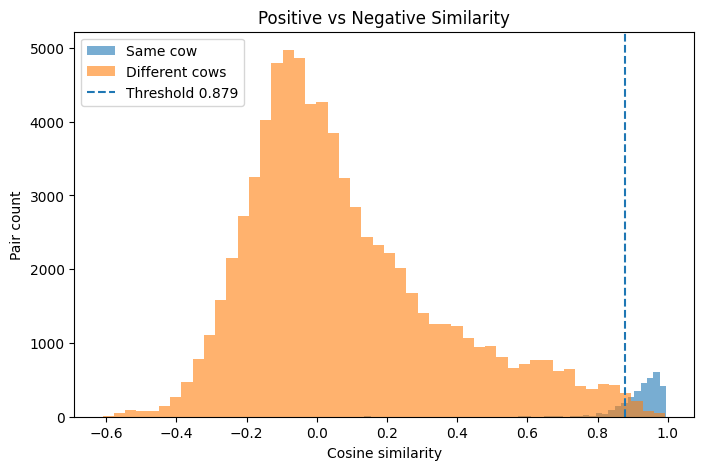

In [ ]:
import matplotlib.pyplot as plt

def plot_similarity_histogram(model, loader, device):
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            embeddings = model(images)
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels.cpu())

    embeddings = torch.cat(all_embeddings)
    labels = torch.cat(all_labels)

    sim_matrix = embeddings @ embeddings.T
    label_matrix = labels.unsqueeze(1) == labels.unsqueeze(0)
    mask = ~torch.eye(len(labels), dtype=torch.bool)

    pos_sim = sim_matrix[mask & label_matrix].numpy()
    neg_sim = sim_matrix[mask & ~label_matrix].numpy()

    plt.figure(figsize=(8, 5))
    plt.hist(pos_sim, bins=50, alpha=0.6, label="Same cow")
    plt.hist(neg_sim, bins=50, alpha=0.6, label="Different cows")
    plt.axvline(threshold, linestyle="--", label=f"Threshold {threshold:.3f}")
    plt.xlabel("Cosine similarity")
    plt.ylabel("Pair count")
    plt.legend()
    plt.title("Positive vs Negative Similarity")
    plt.show()

plot_similarity_histogram(model, val_loader, device)

In [ ]:
def get_embedding(model, image_path, transform, device):
    img = Image.open(image_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model(img)

    return emb

image1_path = "/content/drive/MyDrive/Cow Verification System/cow-cropped_muzzle_dataset/train/776_jpg.rf.2624f80f0999a3b3b2f74bc16b78a66c_0.jpg"
image2_path = "/content/drive/MyDrive/Cow Verification System/cow-cropped_muzzle_dataset/train/778_jpg.rf.ef9acc284083d47318a83ec3956ba5d7_0.jpg"

emb1 = get_embedding(model, image1_path, val_transform, device)
emb2 = get_embedding(model, image2_path, val_transform, device)

cos_sim = F.cosine_similarity(emb1, emb2).item()

print(f"Cosine similarity: {cos_sim:.4f}")

if cos_sim >= threshold:
    print("Result: Same cow / Highly similar")
else:
    print("Result: Different cows")

Cosine similarity: 0.9557
Result: Same cow / Highly similar
